# Phase 2 — Decision Engine (Impact × Effort, Budget‑constrained)

This notebook turns your EDA into **decisions under constraints**. It ranks and simulates **growth levers** (Retention, Expansion, Pricing) by **Net ARR impact per € spent**, with:
- Clear **assumptions** (ROI, caps, targets)
- **Segment × Region** targeting
- **Budget** constraint and a **greedy optimizer** (simple, explainable)
- Before/After **KPIs** including **NRR/GRR** and ARR waterfall

> Input: `saas_financial_snapshot.csv` (Phase 1 output).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

DF_PATH = 'saas_financial_snapshot.csv'
df0 = pd.read_csv(DF_PATH)
assert set(['annual_contract_value','new_arr','churned_arr','net_arr_change','segment','region','industry']).issubset(df0.columns)
print('Loaded:', df0.shape)

Loaded: (500, 11)


## 1) Baseline KPIs (board‑level)

In [2]:
def kpis(df):
    arr = df['annual_contract_value'].sum()
    churn = df['churned_arr'].sum()
    expansion = df.get('expansion_arr', pd.Series(0, index=df.index)).sum()
    contraction = df.get('contraction_arr', pd.Series(0, index=df.index)).sum()
    net = df['net_arr_change'].sum() if 'net_arr_change' in df.columns else (df['new_arr'].sum() + expansion - contraction - churn)
    grr = 1 - (churn/arr if arr>0 else 0)  # Gross retention
    nrr = (arr + expansion - contraction - churn)/arr if arr>0 else 0
    return {
        'ARR': arr,
        'Churned': churn,
        'Expansion': expansion,
        'Contraction': contraction,
        'Net': net,
        'GRR': grr,
        'NRR': nrr,
    }

base = kpis(df0)
base

{'ARR': np.int64(14622660),
 'Churned': np.int64(9986280),
 'Expansion': np.int64(0),
 'Contraction': np.int64(0),
 'Net': np.int64(4636380),
 'GRR': np.float64(0.31706816680412453),
 'NRR': np.float64(0.3170681668041246)}

### ARR Waterfall (baseline)
> Stock → Expansion → Contraction → Churn = Net

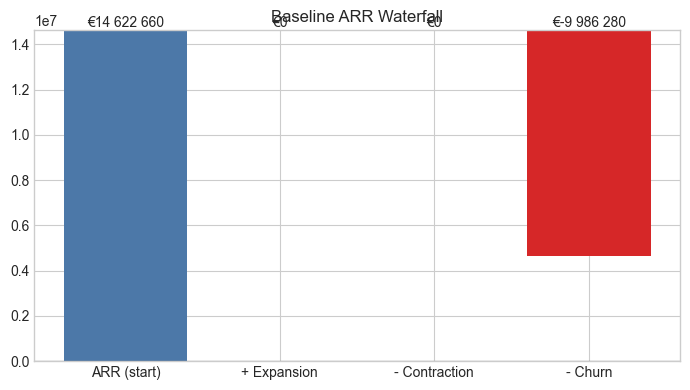

In [3]:
def plot_waterfall(stats, title='ARR Waterfall'):
    parts = [
        ('ARR (start)', stats['ARR']),
        ('+ Expansion', stats['Expansion']),
        ('- Contraction', -stats['Contraction']),
        ('- Churn', -stats['Churned']),
    ]
    vals = [p[1] for p in parts]
    cum = [stats['ARR']]
    for v in vals[1:]:
        cum.append(cum[-1] + v)
    x = np.arange(len(parts))
    colors = ['#4c78a8','#2ca02c','#ff7f0e','#d62728']
    fig, ax = plt.subplots(figsize=(7,4))
    running = stats['ARR']
    for i,(lab,val,col) in enumerate(zip([p[0] for p in parts], vals, colors)):
        if i==0:
            ax.bar(i, val, color=col)
            ax.text(i, val, f"€{val:,.0f}".replace(',', ' '), ha='center', va='bottom')
        else:
            ax.bar(i, val, bottom=running if val<0 else 0, color=col)
            ax.text(i, running+val if val>0 else running, f"€{val:,.0f}".replace(',', ' '), ha='center', va='bottom')
            running += val
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([p[0] for p in parts])
    ax.set_title(title)
    plt.tight_layout(); plt.show()

plot_waterfall(base, 'Baseline ARR Waterfall')

## 2) Scenario Parameters (tune for your case)
- `BUDGET_EUR`: total spend allowed
- `ROI_RETENTION`: **€ retained per € spent** to reduce churn on target scope
- `ROI_EXPANSION`: **€ expansion per € spent** on target scope
- `ROI_PRICING`: **€ uplift per € spent** (optional; can be set very high to model low cost)
- Caps: `MAX_RETENTION_PCT`, `MAX_EXPANSION_PCT`, `MAX_PRICING_UPLIFT_PCT` on targeted scope
> All impacts are applied **on the targeted subset only** (segment × region filters).

In [4]:
# Budget & ROI assumptions (editable)
BUDGET_EUR = 250_000
ROI_RETENTION = 3.0   # each € buys 3€ churn prevented
ROI_EXPANSION = 1.5   # each € buys 1.5€ expansion
ROI_PRICING   = 10.0  # each € buys 10€ uplift (acts like low cost)

MAX_RETENTION_PCT = 0.30   # at most 30% of churn can be prevented on target scope
MAX_EXPANSION_PCT = 0.10   # at most 10% expansion on target scope
MAX_PRICING_UPLIFT_PCT = 0.04  # at most +4% price uplift on target scope

TARGET_SEGMENTS = ['SMB','Mid-Market','Enterprise']
TARGET_REGIONS  = ['NA','EMEA','APAC']


## 3) Levers & Engine
We model **three levers** with **linear ROI** for simplicity and transparency.
- **Retention**: reduce `churned_arr` by `impact_eur = min(MAX_RETENTION_PCT*churn_scope, ROI_RETENTION*spend)`
- **Expansion**: increase `expansion_arr` by `impact_eur = min(MAX_EXPANSION_PCT*arr_scope, ROI_EXPANSION*spend)`
- **Pricing**: increase price (treated as expansion) `impact_eur = min(MAX_PRICING_UPLIFT_PCT*arr_scope, ROI_PRICING*spend)`

A **greedy optimizer** ranks atomic candidates by **Net ARR gained per €** and selects until budget is exhausted.


In [10]:
def scope_mask(df, segments=None, regions=None):
    m = pd.Series(True, index=df.index)
    if segments is not None:
        m &= df['segment'].isin(segments)
    if regions is not None:
        m &= df['region'].isin(regions)
    return m

# ensure required columns
for col in ['expansion_arr','contraction_arr']:
    if col not in df0.columns:
        df0[col] = 0.0

# force numeric columns to float to avoid int64 assignment issues
float_cols = ['annual_contract_value', 'new_arr', 'churned_arr', 'net_arr_change', 'expansion_arr', 'contraction_arr']
for col in float_cols:
    if col in df0.columns:
        df0[col] = df0[col].astype('float64')
    else:
        df0[col] = 0.0


def apply_retention(df, mask, spend, roi=ROI_RETENTION, cap_pct=MAX_RETENTION_PCT):
    out = df.copy()
    churn_scope = out.loc[mask, 'churned_arr'].sum()
    max_impact = cap_pct * churn_scope
    impact = min(max_impact, roi * spend)
    if churn_scope>0 and impact>0:
        # scale down churned_arr proportionally on scope
        factor = (churn_scope - impact)/churn_scope
        out.loc[mask, 'churned_arr'] *= factor
    return out, impact


def apply_expansion(df, mask, spend, roi=ROI_EXPANSION, cap_pct=MAX_EXPANSION_PCT):
    out = df.copy()
    arr_scope = out.loc[mask, 'annual_contract_value'].sum()
    max_impact = cap_pct * arr_scope
    impact = min(max_impact, roi * spend)
    if impact>0:
        out.loc[mask, 'expansion_arr'] += impact * (out.loc[mask,'annual_contract_value']/arr_scope if arr_scope>0 else 0)
    return out, impact


def apply_pricing(df, mask, spend, roi=ROI_PRICING, cap_pct=MAX_PRICING_UPLIFT_PCT):
    out = df.copy()
    arr_scope = out.loc[mask, 'annual_contract_value'].sum()
    max_impact = cap_pct * arr_scope
    impact = min(max_impact, roi * spend)
    if impact>0:
        out.loc[mask, 'expansion_arr'] += impact * (out.loc[mask,'annual_contract_value']/arr_scope if arr_scope>0 else 0)
    return out, impact


def recompute_net(out):
    out['net_arr_change'] = out['new_arr'] + out['expansion_arr'] - out['contraction_arr'] - out['churned_arr']
    return out


### 3.1 Candidate grid (segment × region × lever)
We build **atomic levers** with a **unit spend** (e.g., 10k€) so we can rank by **€/€** easily.

In [11]:
UNIT_SPEND = 10_000  # granularity for greedy selection

from itertools import product

candidates = []
for seg, reg, lever in product(TARGET_SEGMENTS, TARGET_REGIONS, ['Retention','Expansion','Pricing']):
    candidates.append({'segment':seg, 'region':reg, 'lever':lever})

cand_df = pd.DataFrame(candidates)
print(cand_df.head())

  segment region      lever
0     SMB     NA  Retention
1     SMB     NA  Expansion
2     SMB     NA    Pricing
3     SMB   EMEA  Retention
4     SMB   EMEA  Expansion


### 3.2 Rank candidates by impact per € (one unit spend)

In [12]:
def simulate_unit_impact(df, row):
    m = scope_mask(df, [row['segment']], [row['region']])
    if row['lever']=='Retention':
        tmp, imp = apply_retention(df, m, UNIT_SPEND)
    elif row['lever']=='Expansion':
        tmp, imp = apply_expansion(df, m, UNIT_SPEND)
    else:
        tmp, imp = apply_pricing(df, m, UNIT_SPEND)
    tmp = recompute_net(tmp)
    delta_net = kpis(tmp)['Net'] - kpis(df)['Net']
    return imp, delta_net, (delta_net/UNIT_SPEND if UNIT_SPEND>0 else 0)

rank_rows = []
for i,row in cand_df.iterrows():
    imp, dnet, roi = simulate_unit_impact(df0, row)
    rank_rows.append({**row, 'unit_spend':UNIT_SPEND, 'impact_eur':imp, 'delta_net':dnet, 'delta_net_per_euro':roi})

rank = pd.DataFrame(rank_rows).sort_values('delta_net_per_euro', ascending=False)
rank.head(12)

,segment,region,lever,unit_spend,impact_eur,delta_net,delta_net_per_euro
23,Enterprise,EMEA,Pricing,10000,60115.20,60115.20,6.011520
5,SMB,EMEA,Pricing,10000,47696.64,47696.64,4.769664
17,Mid-Market,APAC,Pricing,10000,41749.92,41749.92,4.174992
14,Mid-Market,EMEA,Pricing,10000,39275.52,39275.52,3.927552
8,SMB,APAC,Pricing,10000,36987.36,36987.36,3.698736
26,Enterprise,APAC,Pricing,10000,33671.52,33671.52,3.367152
24,Enterprise,APAC,Retention,10000,30000.00,30000.00,3.000000
3,SMB,EMEA,Retention,10000,30000.00,30000.00,3.000000
15,Mid-Market,APAC,Retention,10000,30000.00,30000.00,3.000000
21,Enterprise,EMEA,Retention,10000,30000.00,30000.00,3.000000


### 3.3 Greedy optimizer (until budget)

In [13]:
def greedy_select(df, rank_tbl, budget=BUDGET_EUR):
    spent = 0.0
    plan = []
    cur = df.copy()
    base_net = kpis(cur)['Net']
    for _, r in rank_tbl.iterrows():
        if spent + UNIT_SPEND > budget:
            break
        m = scope_mask(cur, [r['segment']], [r['region']])
        if r['lever']=='Retention':
            cur, imp = apply_retention(cur, m, UNIT_SPEND)
        elif r['lever']=='Expansion':
            cur, imp = apply_expansion(cur, m, UNIT_SPEND)
        else:
            cur, imp = apply_pricing(cur, m, UNIT_SPEND)
        cur = recompute_net(cur)
        new_net = kpis(cur)['Net']
        plan.append({
            'segment': r['segment'], 'region': r['region'], 'lever': r['lever'],
            'spend': UNIT_SPEND, 'impact_eur': imp, 'delta_net': new_net - base_net
        })
        base_net = new_net
        spent += UNIT_SPEND
    return cur, pd.DataFrame(plan)

opt_df, plan = greedy_select(df0, rank, BUDGET_EUR)
plan.head()

,segment,region,lever,spend,impact_eur,delta_net
0,Enterprise,EMEA,Pricing,10000,60115.20,60115.20
1,SMB,EMEA,Pricing,10000,47696.64,47696.64
2,Mid-Market,APAC,Pricing,10000,41749.92,41749.92
3,Mid-Market,EMEA,Pricing,10000,39275.52,39275.52
4,SMB,APAC,Pricing,10000,36987.36,36987.36


## 4) Results — Before/After

In [14]:
base_stats = kpis(df0)
opt_stats  = kpis(opt_df)

summary = pd.DataFrame([base_stats,opt_stats], index=['Baseline','Optimized'])
summary['GRR_%'] = (summary['GRR']*100).round(1)
summary['NRR_%'] = (summary['NRR']*100).round(1)
summary.round(0)

,ARR,Churned,Expansion,Contraction,Net,GRR,NRR,GRR_%,NRR_%
Baseline,14622660.0,9986280.0,0.0,0.0,4636380.0,0.0,0.0,32.0,32.0
Optimized,14622660.0,9806280.0,349496.0,0.0,5165876.0,0.0,0.0,33.0,35.0


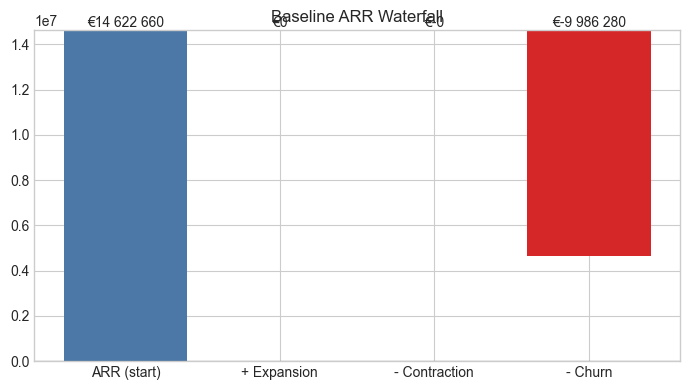

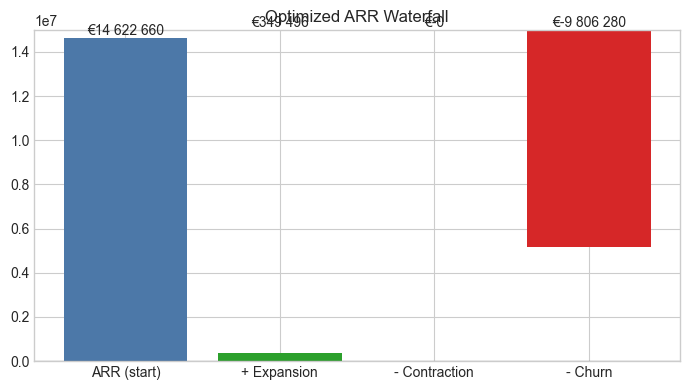

In [15]:
plot_waterfall(base_stats, 'Baseline ARR Waterfall')
plot_waterfall(opt_stats, 'Optimized ARR Waterfall')

### 4.1 Where the value comes from (top allocations)

In [16]:
top_alloc = plan.groupby(['lever','segment','region']).agg(spend=('spend','sum'), impact=('impact_eur','sum'), gain=('delta_net','max')).sort_values('gain', ascending=False).head(12)
top_alloc

spend    impact      gain
lever     segment    region                           
Pricing   Enterprise EMEA    10000  60115.20  60115.20
          SMB        EMEA    10000  47696.64  47696.64
          Mid-Market APAC    10000  41749.92  41749.92
                     EMEA    10000  39275.52  39275.52
          SMB        APAC    10000  36987.36  36987.36
          Enterprise APAC    10000  33671.52  33671.52
Retention Mid-Market EMEA    10000  30000.00  30000.00
          Enterprise APAC    10000  30000.00  30000.00
                     EMEA    10000  30000.00  30000.00
          Mid-Market APAC    10000  30000.00  30000.00
          SMB        EMEA    10000  30000.00  30000.00
                     APAC    10000  30000.00  30000.00

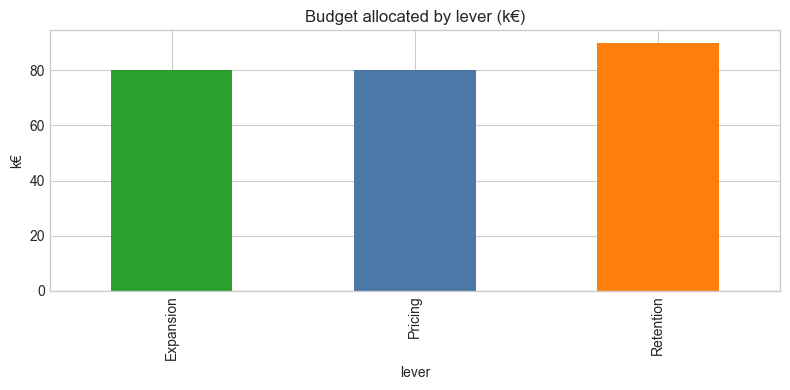

In [17]:
plt.figure(figsize=(8,4))
(plan.groupby('lever')['spend'].sum()/1e3).plot(kind='bar', color=['#2ca02c','#4c78a8','#ff7f0e'])
plt.title('Budget allocated by lever (k€)')
plt.ylabel('k€')
plt.tight_layout(); plt.show()

### 4.2 Heatmap — Net/ARR région (Before vs After)
We reuse the Phase‑1 normalization so prioritization remains comparable.

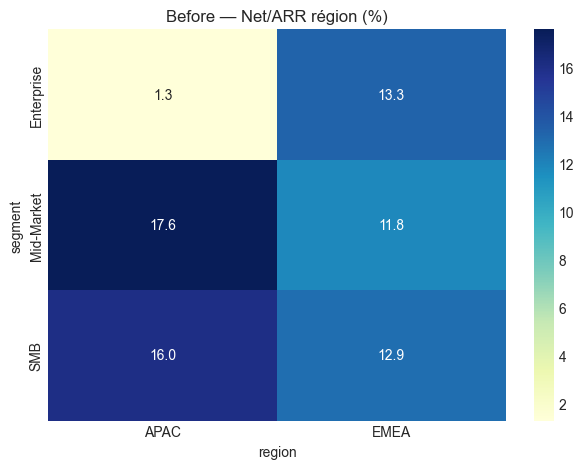

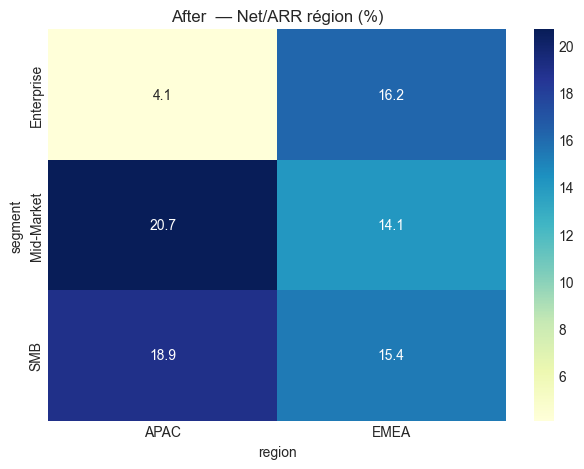

In [18]:
def heat_pct(df, title):
    pivot_abs = df.pivot_table(index='segment', columns='region', values='net_arr_change', aggfunc='sum', fill_value=0)
    arr_by_region = df.groupby('region')['annual_contract_value'].sum()
    pct = pivot_abs.copy()
    for c in pct.columns:
        denom = arr_by_region.get(c, 0)
        pct[c] = pct[c]/denom if denom>0 else 0
    sns.heatmap(pct*100, annot=True, fmt='.1f', cmap='YlGnBu')
    plt.title(title); plt.tight_layout(); plt.show()

heat_pct(df0,  'Before — Net/ARR région (%)')
heat_pct(opt_df,'After  — Net/ARR région (%)')

## 5) How to use this like a consultant
- Tune **ROI** & **caps** with Product/CS/Finance to reflect feasibility
- Lock **TARGET_SEGMENTS/REGIONS** to strategic bets
- Export **`plan`** and the **Before/After** tables into your slide deck
- If needed, replace the greedy step with a formal solver (knapsack/ILP)

> **Deliverable**: a slide with **ranked levers**, **budget allocation**, and **expected NRR/GRR** uplift.
